# Parallelization

This pattern enables additional efficiencies by running multiple sub-tasks in parallel and then collecting results for synthesis. Use cases include: deep research, travel planning, customer feedback analysis, etc.

> **🧭 When to use this pattern — and how Flyte helps**
>
> Use parallelization when a workflow contains independent operations that can run at once — fanning out to several APIs, processing data chunks, or generating multiple drafts to synthesize later. Flyte runs the branches concurrently with `asyncio.gather` / `flyte.map`, each in its own container, joining typed results (use `return_exceptions=True` so one failure doesn't sink the batch).

## Implementation with Flyte v2

This notebook refactors the LangChain `RunnableParallel` example to use Flyte v2 and the native Anthropic client. The three parallel sub-tasks (summarize, questions, key terms) run as Flyte tasks that can execute in parallel containers when run remotely.

#### LangChain vs Flyte v2 — Key Differences

In the context of this pattern, these are the main differences between LangChain and Flyte V2:

| Aspect | LangChain | Flyte v2 |
|--------|-----------|----------|
| **Parallel execution** | `RunnableParallel` (LCEL) | `asyncio.gather` + Flyte tasks |
| **LLM calls** | `ChatOpenAI` via LCEL | Direct `AsyncAnthropic` client |
| **Caching** | None | `cache="auto"` per task |
| **Execution** | In-process only | Local or remote (containers) |
| **Dependencies** | langchain-openai, langchain-core | flyte, anthropic |

1. Install dependencies

In [ ]:
!uv pip install flyte anthropic

Using Python 3.12.12 environment at: /Users/davidmirror/code/agentic-patterns-on-v2/.venv
Audited 2 packages in 3ms


### Start the devbox

If you haven't already, install the flyte package with the command above, then launch the local cluster:

In [ ]:
!flyte start devbox

2. Export your API key

In [ ]:
!flyte create secret ANTHROPIC_API_KEY --value sk-...


3. Import dependencies and configure the Flyte TaskEnvironment

In [1]:
import os
import asyncio
import flyte
from flyte import TaskEnvironment, Resources, Secret

flyte.init_from_config()

env = TaskEnvironment(
    name="parallel_env",
    resources=Resources(cpu="1", memory="1Gi"),
    cache="auto",
    image=flyte.Image.from_debian_base().with_pip_packages("anthropic>=0.25.0"),
    secrets=[Secret(key="ANTHROPIC_API_KEY", as_env_var="ANTHROPIC_API_KEY")],
)


4. Define the three parallel sub-tasks and the synthesis task

Each sub-task is a Flyte task that calls Anthropic directly. When run remotely, Flyte schedules them in parallel containers.

In [2]:
async def _llm_call(system: str, user: str) -> str:
    """Helper: single LLM call with system + user messages."""
    from anthropic import AsyncAnthropic
    client = AsyncAnthropic()
    resp = await client.messages.create(
        model="claude-haiku-4-5-20251001",
        max_tokens=1024,
        system=system,
        messages=[{"role": "user", "content": user}],
    )
    return resp.content[0].text.strip()


@env.task
async def summarize_task(topic: str) -> str:
    """Summarize the topic concisely."""
    return await _llm_call(
        "Summarize the following topic concisely:",
        topic,
    )


@env.task
async def questions_task(topic: str) -> str:
    """Generates questions about the topic."""
    return await _llm_call(
        "Generate three interesting questions about the following topic:",
        topic,
    )


@env.task
async def terms_task(topic: str) -> str:
    """Identify 5-10 key terms from the topic, comma-separated."""
    return await _llm_call(
        "Identify 5-10 key terms from the following topic, separated by commas:",
        topic,
    )


@env.task
async def synthesize_task(
    topic: str, summary: str, questions: str, key_terms: str
) -> str:
    """Synthesize a comprehensive answer from the parallel results."""
    system = """Based on the following information:
Summary: {summary}
Related Questions: {questions}
Key Terms: {key_terms}
Synthesize a comprehensive answer."""
    return await _llm_call(
        system.format(summary=summary, questions=questions, key_terms=key_terms),
        f"Original topic: {topic}",
    )


5. Orchestrate the parallel workflow

The main task runs the three sub-tasks in parallel with `asyncio.gather`. Flyte schedules them concurrently (locally or in separate containers when remote).

In [3]:
@env.task
async def parallel_research(topic: str) -> str:
    """Run summarize, questions, and terms in parallel, then synthesize."""
    summary, questions, key_terms = await asyncio.gather(
        summarize_task(topic),
        questions_task(topic),
        terms_task(topic),
    )
    return await synthesize_task(topic, summary, questions, key_terms)

6. Run on the devbox

In [4]:
run = flyte.run(parallel_research, topic="The history of space exploration")
run.wait()
print(run.outputs()[0])


> Building 1 image...

> Building image flyte for environment parallel_env

> Image localhost:30000/flyte:604924cfea83e0c91cf26689e267fd6c not found, building...

05:52:35.179453 WARNING   docker_builder.py:755 - Temporary directory: /var/folders/59/q0qx_fx10bxbxhpkyrcs79sr0000gn/T/tmpt8uce6zd

Run command: docker buildx build --builder flytex --tag localhost:30000/flyte:604924cfea83e0c91cf26689e267fd6c --platform linux/amd64,linux/arm64 --push /var/folders/59/q0qx_fx10bxbxhpkyrcs79sr0000gn/T/tmpt8uce6zd 


#0 building with "flytex" instance using docker-container driver

#1 [internal] load build definition from Dockerfile
#1 transferring dockerfile: 1.14kB done
#1 DONE 0.0s

#2 resolve image config for docker-image://docker.io/docker/dockerfile:1.10
#2 ...

#3 [auth] docker/dockerfile:pull token for registry-1.docker.io
#3 DONE 0.0s

#2 resolve image config for docker-image://docker.io/docker/dockerfile:1.10
#2 DONE 1.1s

#4 docker-image://docker.io/docker/dockerfile:1.10@sha256:865e5dd094beca432e8c0a1d5e1c465db5f998dca4e439981029b3b81fb39ed5
#4 resolve docker.io/docker/dockerfile:1.10@sha256:865e5dd094beca432e8c0a1d5e1c465db5f998dca4e439981029b3b81fb39ed5 done
#4 CACHED

#5 [linux/arm64 internal] load metadata for ghcr.io/flyteorg/flyte:py3.12-v2.4.0
#5 ...

#6 [auth] astral-sh/uv:pull token for ghcr.io
#6 DONE 0.0s

#7 [auth] flyteorg/flyte:pull token for ghcr.io
#7 DONE 0.0s

#8 [linux/arm64 internal] load metadata for ghcr.io/astral-sh/uv:0.8.13
#8 ...

#9 [linux/amd64 internal] load

✓ Built image for environment parallel_env: localhost:30000/flyte:604924cfea83e0c91cf26689e267fd6c

Output()

# A Comprehensive Overview of Space Exploration History

Space exploration represents humanity's most ambitious endeavor to understand and traverse the cosmos. This journey spans from the earliest artificial satellites to today's commercial spaceflight industry, fundamentally transforming our technological capabilities and our understanding of the universe.

## The Foundation: Early Era (1950s-1960s)

The space age began with geopolitical competition. The Soviet Union's launch of **Sputnik 1** in 1957 shocked the world and ignited the Space Race—a Cold War competition that would define an entire era. This event demonstrated that humans had achieved the capability to reach beyond Earth's atmosphere, spurring nations to invest heavily in aerospace technology.

The early human spaceflight achievements followed rapidly: **Yuri Gagarin's** 1961 orbital flight established Soviet superiority in human spaceflight, while **John Glenn's** 1962 orbit in 1962 reasserted American credibility. Howev

The timeline in the UI shows the three tasks ran in parallel:

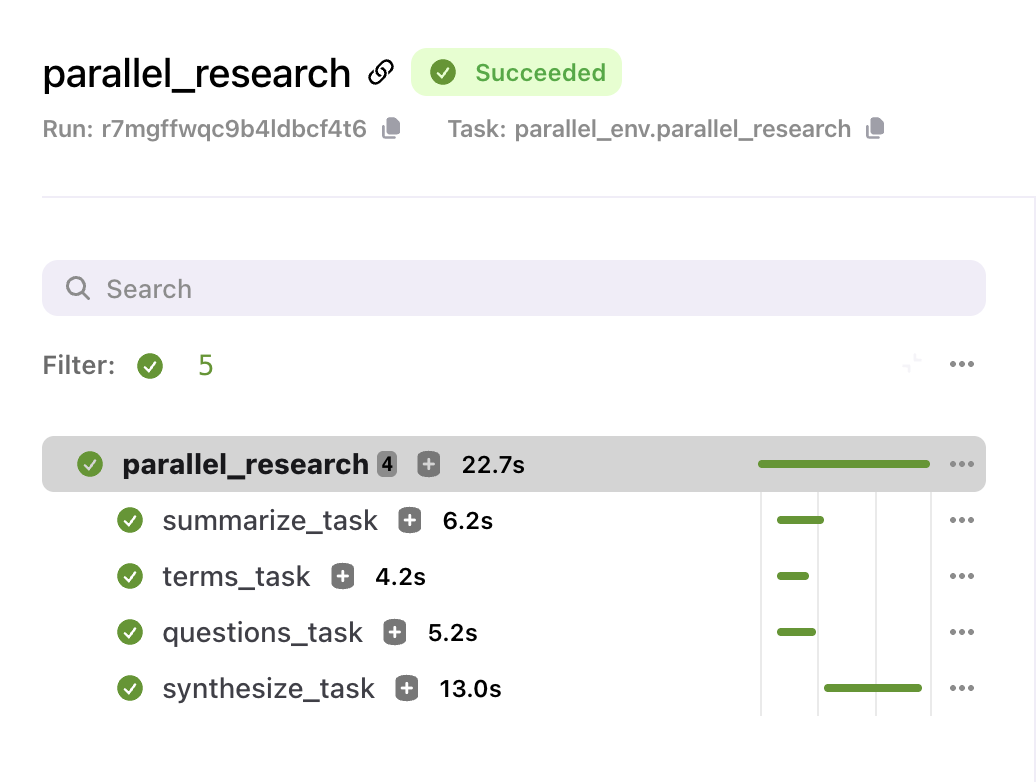

## Scaling the pattern

Use `ReusePolicy` to keep a pool of warm containers instead of starting a new one per action. When you have multiple short tasks (LLM calls) where container startup time dominates overall latency, Flyte's reusable containers eliminate that factor by enabling the action to run in an already-warm container. [Learn more](https://www.union.ai/docs/v2/union/user-guide/task-configuration/reusable-containers/)

> **Note:** `ReusePolicy` is a Union-specific feature that requires a [Union deployment](https://www.union.ai/docs/v2/union/). It is not supported on the local devbox.

In [ ]:
from datetime import timedelta

reusable_image = flyte.Image.from_debian_base().with_pip_packages("unionai-reuse>=0.1.10")

env = flyte.TaskEnvironment(
    name="reusable-env",
    resources=flyte.Resources(memory="1Gi", cpu="500m"),
    reusable=flyte.ReusePolicy(
        replicas=2,                           # Create 2 container instances
        concurrency=1,                        # Process 1 task per container at a time
        scaledown_ttl=timedelta(minutes=10),  # Individual containers shut down after 10 minutes of inactivity
        idle_ttl=timedelta(hours=1)           # Entire environment shuts down after 1 hour of no tasks
    ),
    image=reusable_image  # Use the container image augmented with the unionai-reuse library.
)

## Why not the Agent harness here?

Parallelization fans one input out to independent workers and joins the results. The control flow is **static and known ahead of time**, so `asyncio.gather` (or `flyte.map`) over `@env.task`s expresses it directly — and Flyte schedules the branches concurrently for free. An `Agent`'s tool-loop would insert an extra LLM round-trip just to decide what to run, which is pure overhead when the fan-out is fixed.